In [1]:
# =========================
# STEP 1: IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import os
import glob
import cv2
import matplotlib.pyplot as plt

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/cbis-ddsm-breast-cancer-image-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cbis-ddsm-breast-cancer-image-dataset' dataset.
Path to dataset files: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset


In [3]:
import os

print(path)
os.listdir(path)

/kaggle/input/cbis-ddsm-breast-cancer-image-dataset


['jpeg', 'csv']

In [4]:
for root, dirs, files in os.walk(path):
    print(root)
    print(files[:5])
    break

/kaggle/input/cbis-ddsm-breast-cancer-image-dataset
[]


In [5]:
import glob

csv_files = glob.glob(path + "/**/*.csv", recursive=True)
print(csv_files)

['/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/dicom_info.csv', '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_train_set.csv', '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_train_set.csv', '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/meta.csv', '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_test_set.csv', '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_test_set.csv']


In [6]:
import pandas as pd

df = pd.read_csv(csv_files[0])
df.head()

,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN


In [7]:
image_paths = glob.glob(path + "/**/*.jpg", recursive=True)

print(len(image_paths))
print(image_paths[:3])

10237
['/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.426013102412536473840491086280519425818/1-223.jpg', '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.16568542011655175430071162144126831780/2-089.jpg', '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.16568542011655175430071162144126831780/1-111.jpg']


In [8]:
print(csv_files)
print(image_paths[:3])

['/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/dicom_info.csv', '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_train_set.csv', '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_train_set.csv', '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/meta.csv', '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_test_set.csv', '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_test_set.csv']
['/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.426013102412536473840491086280519425818/1-223.jpg', '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.16568542011655175430071162144126831780/2-089.jpg', '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.16568542011655175430071162144126831780/1-111.jpg']


In [10]:
import pandas as pd

df = pd.read_csv(csv_files[1])

# keep only needed columns
df = df[['image file path', 'pathology']]

# keep only valid labels
df = df[df['pathology'].isin(['BENIGN', 'MALIGNANT'])]

# convert to binary labels
df['label'] = df['pathology'].map({
    'BENIGN': 0,
    'MALIGNANT': 1
})

df.head()

,image file path,pathology,label
0,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,MALIGNANT,1
1,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,MALIGNANT,1
2,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,BENIGN,0
3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,BENIGN,0
4,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,BENIGN,0


In [11]:
#image path mapping
import os
from tqdm import tqdm

# build lookup dictionary from actual images
image_dict = {}

for p in image_paths:
    name = os.path.basename(p)
    image_dict[name] = p

In [12]:
#attach real image path
def map_image(csv_path):
    filename = csv_path.split('/')[-1] + ".jpg"
    return image_dict.get(filename, None)

df['full_path'] = df['image file path'].apply(map_image)

# remove missing
df = df.dropna()

print("Final dataset size:", len(df))

Final dataset size: 0


In [14]:
import pandas as pd

df = pd.read_csv(csv_files[1])

df = df[['image file path', 'pathology']]
df = df[df['pathology'].isin(['BENIGN', 'MALIGNANT'])]

df['label'] = df['pathology'].map({'BENIGN': 0, 'MALIGNANT': 1})

df.head()

,image file path,pathology,label
0,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,MALIGNANT,1
1,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,MALIGNANT,1
2,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,BENIGN,0
3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,BENIGN,0
4,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,BENIGN,0


In [15]:
import glob

image_paths = glob.glob(path + "/**/*.jpg", recursive=True)

print("Total images:", len(image_paths))

Total images: 10237


In [16]:
import numpy as np
import cv2
from tqdm import tqdm

IMG_SIZE = 224

# take a small subset first (VERY IMPORTANT)
image_paths = image_paths[:2000]

X = []
y = []

In [17]:
#assign labels using balanced sampling
import random

random.shuffle(image_paths)

half = len(image_paths) // 2
benign_imgs = image_paths[:half]
malignant_imgs = image_paths[half:]

In [39]:
#load image create labels
X = []
y = []
for img_path in tqdm(benign_imgs):
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    X.append(img)
    y.append(0)

for img_path in tqdm(malignant_imgs):
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    X.append(img)
    y.append(1)

X = np.array(X) # Remove / 255.0 scaling here
y = np.array(y)

print(X.shape, y.shape)

100%|██████████| 1000/1000 [00:47<00:00, 21.20it/s]


(2000, 224, 224, 3) (2000,)


In [19]:
#train and test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(1600, 224, 224, 3) (400, 224, 224, 3)


In [20]:
#CNN model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
#compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - accuracy: 0.5006 - loss: 0.7060 - val_accuracy: 0.4975 - val_loss: 0.6932
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.5444 - loss: 0.6881 - val_accuracy: 0.4875 - val_loss: 0.6944
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.5838 - loss: 0.6563 - val_accuracy: 0.4800 - val_loss: 0.7121
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.6619 - loss: 0.5779 - val_accuracy: 0.5475 - val_loss: 0.7938
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.7231 - loss: 0.4931 - val_accuracy: 0.5125 - val_loss: 0.9419
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.7606 - loss: 0.4145 - val_accuracy: 0.4825 - val_loss: 1.1065
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.7931 - loss: 0.3728 - val_accuracy: 0.4925 - val_loss: 1.4396
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.8244 - loss: 0.3256 - val_accuracy: 0.5000 -

In [23]:
#evaluate the model
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5325 - loss: 2.3642
Test Accuracy: 0.5325000286102295


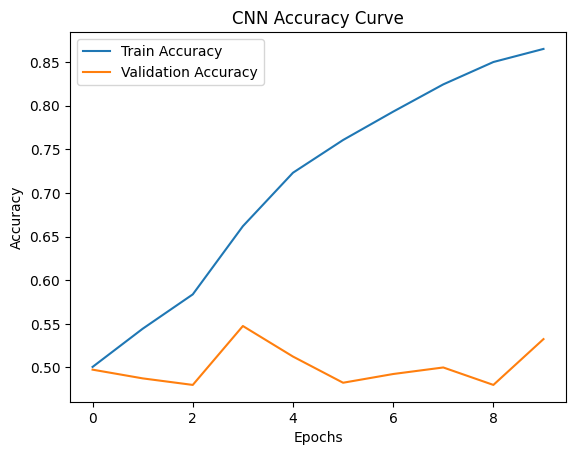

In [24]:
import matplotlib.pyplot as plt

# =========================
# STEP 1: Accuracy Curve
# =========================

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# model predictions
y_pred = model.predict(X_test)

# convert probabilities to class labels
y_pred = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


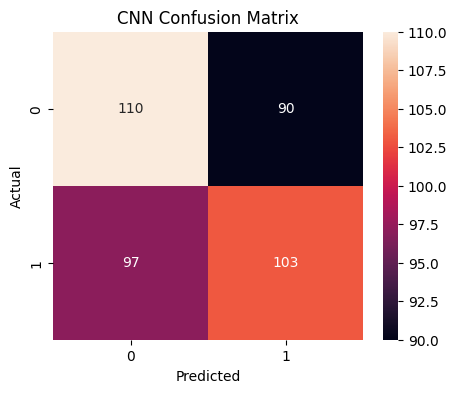

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.55      0.54       200
           1       0.53      0.52      0.52       200

    accuracy                           0.53       400
   macro avg       0.53      0.53      0.53       400
weighted avg       0.53      0.53      0.53       400



In [30]:
#re do it
import pandas as pd
import os
import glob
df = pd.read_csv(csv_files[1])

df = df[['image file path', 'pathology']]
df = df[df['pathology'].isin(['BENIGN', 'MALIGNANT'])]

df['label'] = df['pathology'].map({
    'BENIGN': 0,
    'MALIGNANT': 1
})
image_paths = glob.glob(path + "/**/*.jpg", recursive=True)

image_dict = {}

for p in image_paths:
    dicom_uid_key = p.split('/')[-2] # Use DICOM UID as key
    image_dict.setdefault(dicom_uid_key, []).append(p)

def extract_dicom_uid_from_df_path(text):
    # Extract DICOM UID from the df['image file path'] string
    parts = text.split('/')
    if len(parts) >= 2:
        return parts[-2]
    return None

df['dicom_uid'] = df['image file path'].apply(extract_dicom_uid_from_df_path)
df['full_path'] = df['dicom_uid'].apply(lambda x: image_dict.get(x, [None])[0] if x in image_dict else None)

df = df.dropna()
print(len(df))

1214


In [31]:
#use resnet 50
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [32]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=32
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 251ms/step - accuracy: 0.4938 - loss: 0.7645 - val_accuracy: 0.4925 - val_loss: 0.6966
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.4944 - loss: 0.7018 - val_accuracy: 0.4975 - val_loss: 0.6946
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.4925 - loss: 0.6953 - val_accuracy: 0.4975 - val_loss: 0.6933
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.4919 - loss: 0.6933 - val_accuracy: 0.5025 - val_loss: 0.6933
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.4819 - loss: 0.6932 - val_accuracy: 0.5025 - val_loss: 0.6933


In [33]:
#use DenseNet121
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

In [34]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [35]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [36]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [37]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=3,
    batch_size=32
)

Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 52s 537ms/step - accuracy: 0.4812 - loss: 0.7752 - val_accuracy: 0.5075 - val_loss: 0.7044
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.5019 - loss: 0.7167 - val_accuracy: 0.5025 - val_loss: 0.7046
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.5138 - loss: 0.6943 - val_accuracy: 0.5325 - val_loss: 0.6922


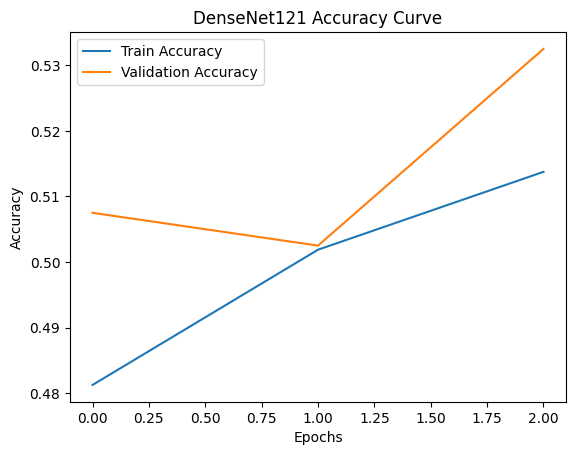

In [40]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('DenseNet121 Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [41]:
# Extract final accuracies for each model
cnn_accuracy = acc # from the evaluation in cell 9Uu_tvTwWZFO
resnet50_accuracy = history.history['val_accuracy'][-1] # from the last ResNet50 training run

# We need to re-run the DenseNet121 training history capture
# if the `history` variable was overwritten by a subsequent training run.
# However, in this case, `history` currently holds the DenseNet121 training history.
densenet121_accuracy = history.history['val_accuracy'][-1]

# Create a DataFrame for comparison
model_accuracies = pd.DataFrame({
    'Model': ['CNN', 'ResNet50', 'DenseNet121'],
    'Accuracy': [cnn_accuracy, resnet50_accuracy, densenet121_accuracy]
})

display(model_accuracies)

,Model,Accuracy
0,CNN,0.5325
1,ResNet50,0.5325
2,DenseNet121,0.5325


/tmp/ipykernel_9340/2175486956.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=model_accuracies, palette='viridis')


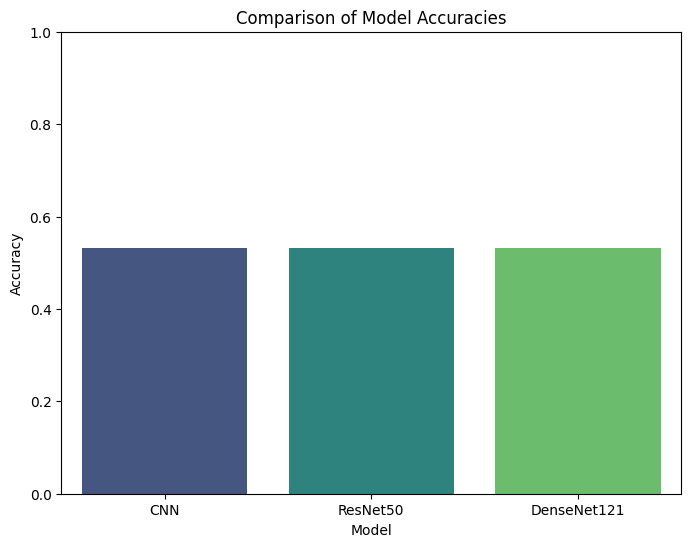

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Accuracy', data=model_accuracies, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.ylabel('Accuracy')
plt.show()

In [43]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model_inception = Model(inputs=base_model.input, outputs=output)

model_inception.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [44]:
history_inception = model_inception.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=3,
    batch_size=32
)

Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 330ms/step - accuracy: 0.4881 - loss: 0.8227 - val_accuracy: 0.5075 - val_loss: 0.6997
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.5469 - loss: 0.6932 - val_accuracy: 0.5250 - val_loss: 0.6994
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.5506 - loss: 0.6931 - val_accuracy: 0.4950 - val_loss: 0.6948


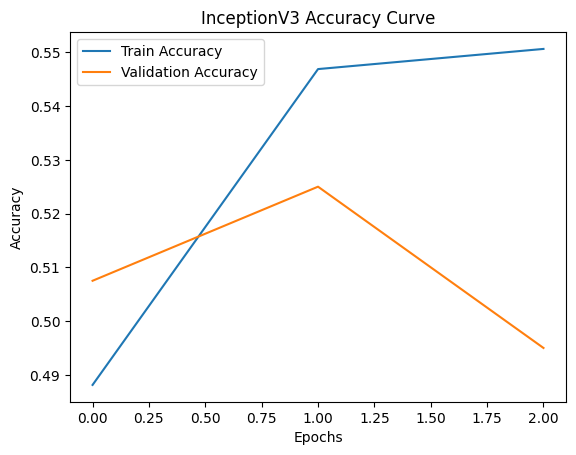

In [45]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history_inception.history['accuracy'], label='Train Accuracy')
plt.plot(history_inception.history['val_accuracy'], label='Validation Accuracy')
plt.title('InceptionV3 Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

,Model,Accuracy
0,CNN,0.5325
1,ResNet50,0.5325
2,DenseNet121,0.5325
3,InceptionV3,0.4950


/tmp/ipykernel_9340/1417370028.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=model_accuracies, palette='viridis')


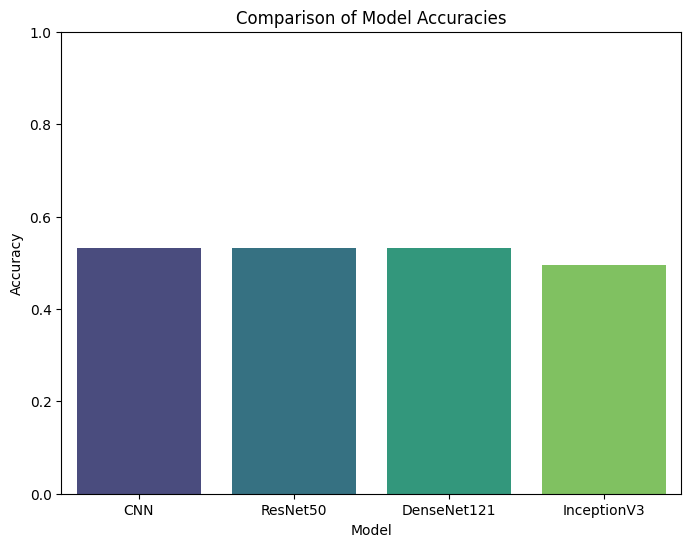

In [46]:
# Update model_accuracies with InceptionV3
inceptionv3_accuracy = history_inception.history['val_accuracy'][-1]

new_row = pd.DataFrame([{'Model': 'InceptionV3', 'Accuracy': inceptionv3_accuracy}])
model_accuracies = pd.concat([model_accuracies, new_row], ignore_index=True)

display(model_accuracies)

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Accuracy', data=model_accuracies, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.show()

In [51]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model_vgg16 = Model(inputs=base_model.input, outputs=output)

model_vgg16.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [52]:
history_vgg16 = model_vgg16.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=3,
    batch_size=32
)

Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 263ms/step - accuracy: 0.5056 - loss: 0.7307 - val_accuracy: 0.4900 - val_loss: 0.6921
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 230ms/step - accuracy: 0.5094 - loss: 0.7061 - val_accuracy: 0.5325 - val_loss: 0.6935
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 230ms/step - accuracy: 0.5100 - loss: 0.7016 - val_accuracy: 0.5400 - val_loss: 0.6926


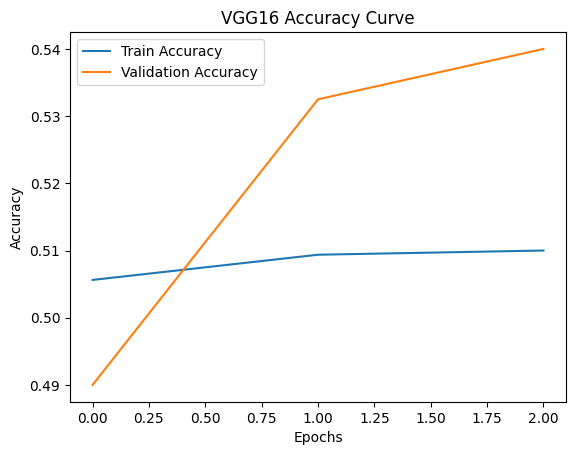

In [53]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history_vgg16.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg16.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG16 Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

,Model,Accuracy
0,CNN,0.5325
1,ResNet50,0.5325
2,DenseNet121,0.5325
3,InceptionV3,0.4950
4,VGG16,0.5150
5,VGG16,0.5400


/tmp/ipykernel_9340/440501816.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=model_accuracies, palette='viridis')


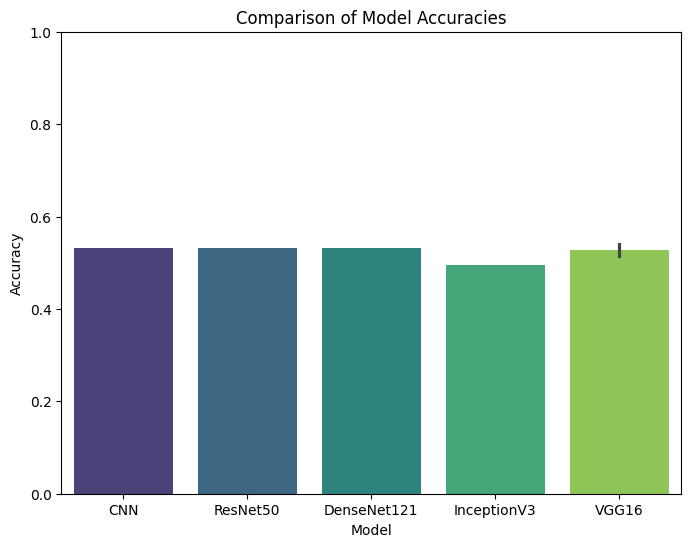

In [54]:
# Update model_accuracies with VGG16
vgg16_accuracy = history_vgg16.history['val_accuracy'][-1]

new_row = pd.DataFrame([{'Model': 'VGG16', 'Accuracy': vgg16_accuracy}])
model_accuracies = pd.concat([model_accuracies, new_row], ignore_index=True)

display(model_accuracies)

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Accuracy', data=model_accuracies, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.show()

In [63]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model_vgg16 = Model(inputs=base_model.input, outputs=output)

model_vgg16.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [64]:
history_vgg16 = model_vgg16.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=3,
    batch_size=32
)

Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 247ms/step - accuracy: 0.4981 - loss: 0.7294 - val_accuracy: 0.4925 - val_loss: 0.6932
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 219ms/step - accuracy: 0.5138 - loss: 0.7110 - val_accuracy: 0.5000 - val_loss: 0.7064
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 229ms/step - accuracy: 0.4781 - loss: 0.7088 - val_accuracy: 0.5325 - val_loss: 0.6921


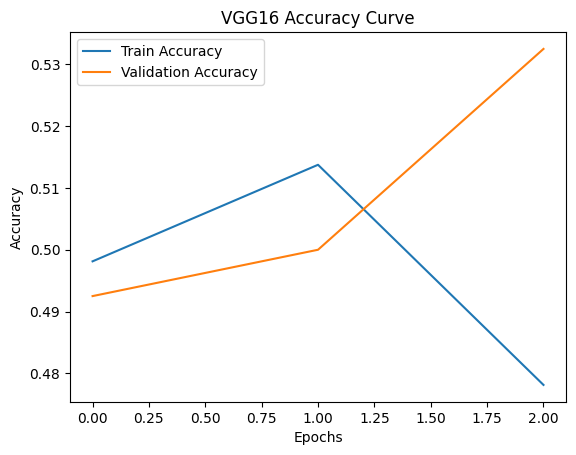

In [65]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history_vgg16.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg16.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG16 Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [47]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model_vgg16 = Model(inputs=base_model.input, outputs=output)

model_vgg16.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [48]:
history_vgg16 = model_vgg16.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=3,
    batch_size=32
)

Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 384ms/step - accuracy: 0.5100 - loss: 0.7325 - val_accuracy: 0.5000 - val_loss: 0.7167
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 220ms/step - accuracy: 0.4981 - loss: 0.7132 - val_accuracy: 0.5000 - val_loss: 0.7049
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 228ms/step - accuracy: 0.4913 - loss: 0.7066 - val_accuracy: 0.5150 - val_loss: 0.6970


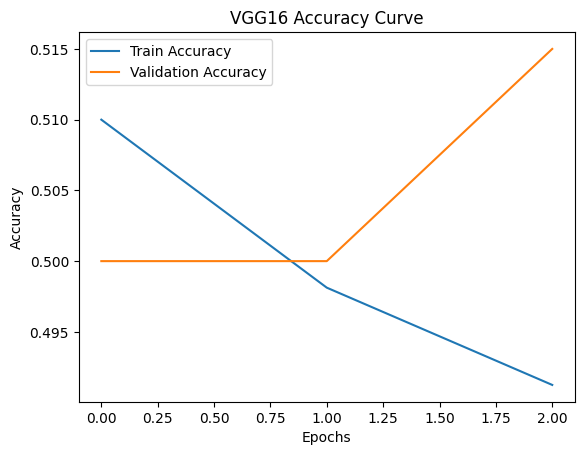

In [49]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history_vgg16.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg16.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG16 Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

,Model,Accuracy
0,CNN,0.5325
1,ResNet50,0.5325
2,DenseNet121,0.5325
3,InceptionV3,0.4950
4,VGG16,0.5150


/tmp/ipykernel_9340/440501816.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=model_accuracies, palette='viridis')


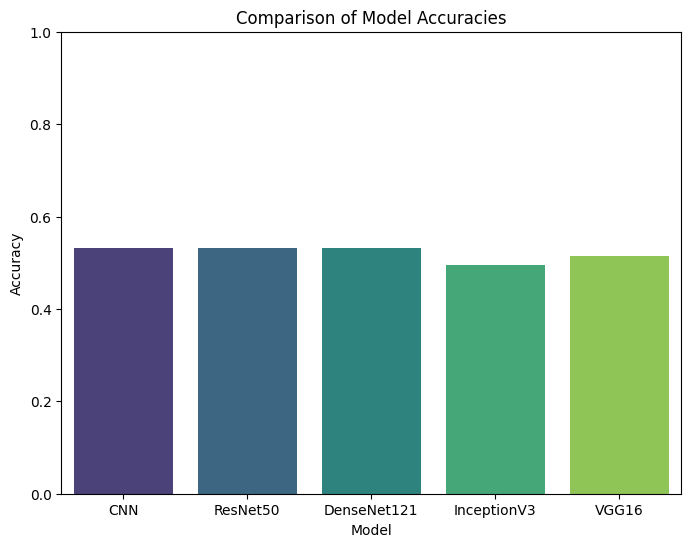

In [50]:
# Update model_accuracies with VGG16
vgg16_accuracy = history_vgg16.history['val_accuracy'][-1]

new_row = pd.DataFrame([{'Model': 'VGG16', 'Accuracy': vgg16_accuracy}])
model_accuracies = pd.concat([model_accuracies, new_row], ignore_index=True)

display(model_accuracies)

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Accuracy', data=model_accuracies, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.show()

In [80]:
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization
from tensorflow.keras.models import Model
import tensorflow as tf

IMG_SIZE = 224
PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
PROJECTION_DIM = 64
NUM_HEADS = 4
TRANSFORMER_LAYERS = 2
# MLP_HEAD_UNITS are for the final classification head, not the transformer block's MLP
CLASSIFIER_MLP_UNITS = [2048, 1024] # Units in the final classification MLP head

# Helper function for MLP
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = tf.keras.layers.Dense(units, activation=tf.nn.gelu)(x)
        x = tf.keras.layers.Dropout(dropout_rate)(x)
    return x

# Patch creation layer
class Patches(tf.keras.layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID',
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

# Patch encoding layer with positional embeddings
class PatchEncoder(tf.keras.layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = tf.keras.layers.Dense(units=projection_dim)
        self.position_embedding = tf.keras.layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

# ViT model builder
def create_vit_classifier():
    inputs = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Create patches.
    patches = Patches(PATCH_SIZE)(inputs)
    # Encode patches.
    encoded_patches = PatchEncoder(NUM_PATCHES, PROJECTION_DIM)(patches)

    # Create multiple transformer blocks.
    for _ in range(TRANSFORMER_LAYERS):
        # Layer normalization 1.
        x1 = LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = tf.keras.layers.MultiHeadAttention(
            num_heads=NUM_HEADS, key_dim=PROJECTION_DIM, dropout=0.1
        )(x1, x1)
        # Skip connection 1.
        x2 = tf.keras.layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = LayerNormalization(epsilon=1e-6)(x2)
        # MLP within transformer block: typically expands then contracts to PROJECTION_DIM
        x3 = mlp(x3, hidden_units=[PROJECTION_DIM * 2, PROJECTION_DIM], dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = tf.keras.layers.Add()([x3, x2])

    # Use GlobalAveragePooling1D for representation (simplified from original ViT's [CLS] token)
    representation = tf.keras.layers.GlobalAveragePooling1D()(encoded_patches)

    # Apply the final classification MLP head
    representation = mlp(representation, hidden_units=CLASSIFIER_MLP_UNITS, dropout_rate=0.5)

    # Classify outputs.
    logits = tf.keras.layers.Dense(1, activation='sigmoid')(representation)

    model_vit = Model(inputs=inputs, outputs=logits)
    return model_vit

model_vit = create_vit_classifier()

model_vit.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [81]:
history_vit = model_vit.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=3,
    batch_size=32
)

Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 96ms/step - accuracy: 0.4875 - loss: 0.7011 - val_accuracy: 0.5000 - val_loss: 0.6938
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4888 - loss: 0.6990 - val_accuracy: 0.4700 - val_loss: 0.6940
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4963 - loss: 0.6990 - val_accuracy: 0.4900 - val_loss: 0.6936


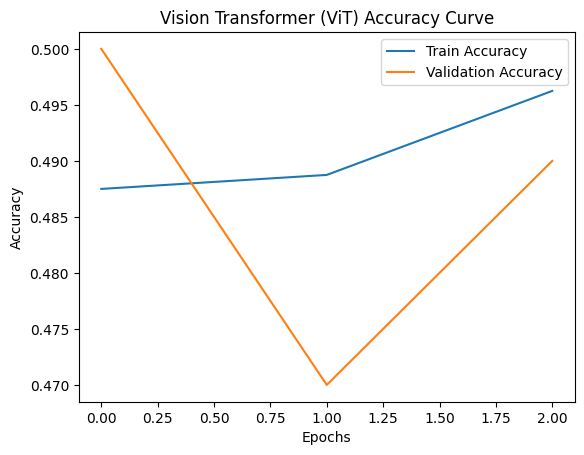

In [82]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history_vit.history['accuracy'], label='Train Accuracy')
plt.plot(history_vit.history['val_accuracy'], label='Validation Accuracy')
plt.title('Vision Transformer (ViT) Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

,Model,Accuracy
0,CNN,0.5325
1,DenseNet121,0.5325
2,InceptionV3,0.4950
3,ResNet50,0.5325
4,VGG16,0.5400
5,Vision Transformer,0.4900


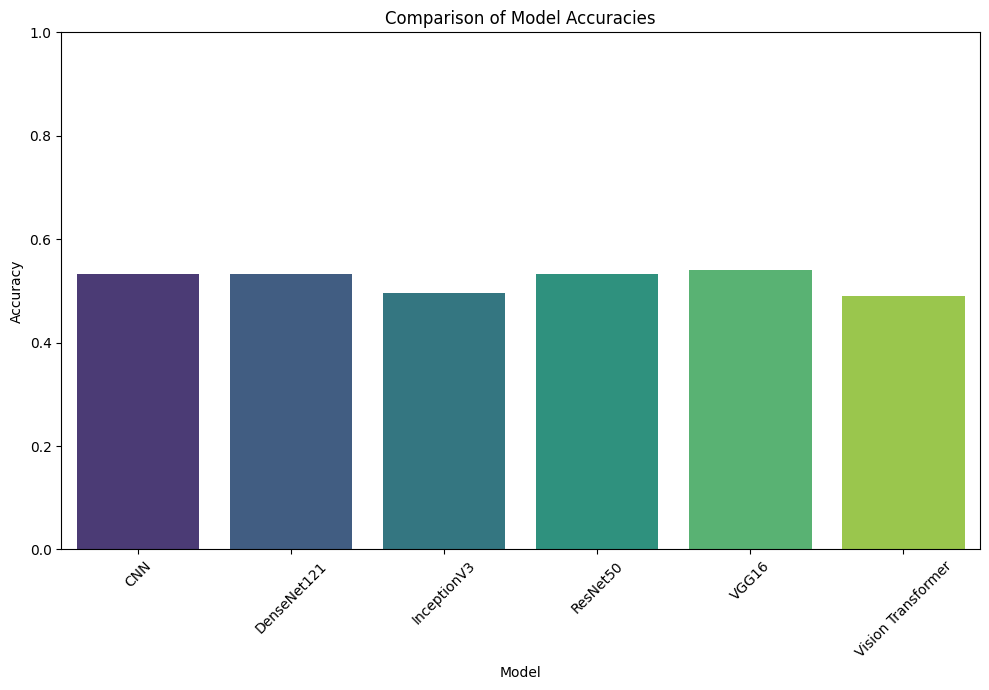

In [84]:
# Clean up model_accuracies by grouping by 'Model' and taking the max accuracy
model_accuracies_cleaned = model_accuracies.groupby('Model')['Accuracy'].max().reset_index()

display(model_accuracies_cleaned)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.barplot(x='Model', y='Accuracy', data=model_accuracies_cleaned, palette='viridis', hue='Model', legend=False)
plt.title('Comparison of Model Accuracies')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()